In [2]:
!pip install japanize-matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 28.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=3728fe93ce877a44c2f528fb7e0393947ed7522a302a83c5399f9434ede67f7d
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd "/content/drive/MyDrive/ソーセージ＿画像フォルダー"

/content/drive/MyDrive/ソーセージ＿画像フォルダー


In [5]:
from PIL import Image,ImageOps
import os, glob
import numpy as np
from PIL import ImageFile
# IOError: image file is truncated (0 bytes not processed)を回避するために必要
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [6]:
# dogsとcatsにある画像の縦、横の長さの平均を計算
import cv2
regions = ["0_北海道新", "1_東北新", "2_関東新", "3_中部新", "4_北陸新","5_近畿新", "6_中国新", "7_四国新", "8_九州新", "9_沖縄新"]

wh = [] # 画像の横の長さを格納するリスト
ht = [] # 画像の縦の長さを格納するリスト

for region in regions:
  photos = glob.glob(region + "/*.png")
  for file in photos:
      photo = cv2.imread(file)
      if photo is not None: # 画像が正常に読み込まれたかを確認
          h, w = photo.shape[:2] # 画像の縦の長さ（h）、横の長さ（w）を取得
          wh.append(w) # w の値を wh に格納
          ht.append(h) # h の値を ht に格納
      else:
          print(f"Warning: Could not read image file: {file}") # 読み込めなかった画像ファイルを出力
ht_resize = int(np.mean(ht)) # ht の値の平均の小数点以下を切り捨てた値を計算
wh_resize = int(np.mean(wh)) # wh の値の平均の小数点以下を切り捨てた値を計算
# ラベル(=リストのインデックス）は、犬を0とし猫を1とする
classes = ["0_北海道新", "1_東北新", "2_関東新", "3_中部新", "4_北陸新","5_近畿新", "6_中国新", "7_四国新", "8_九州新", "9_沖縄新"]
num_classes = len(classes)

X_train = [] # 訓練データを入れる配列
X_test  = [] # テストデータを入れる配列
y_train = [] # 訓練データのラベルを入れる配列
y_test  = [] # テストデータのラベルを入れる配列
#-追加
from sklearn.model_selection import train_test_split

X_all = [] # 全データを入れる配列
y_all = [] # 全ラベルを入れる配列

for index, classlabel in enumerate(classes):
    photos_dir = "./" + classlabel
    files = glob.glob(photos_dir + "/*.png") # png画像を取り込む場合、"/*.jpg"を"/*.png"に変更する
    num_testdata = int(len(files) * 0.2)
    for i, file in enumerate(files):
        image = Image.open(file)
        image = image.convert("RGB") # RGB（赤、緑、青）に変換（画像の配色データをRGBの順に統一）

        # --------------------------------------------------
        # 【修正箇所】無理やりリサイズするのではなく、余白（黒）でパディングする
        # image = image.resize((wh_resize//1, ht_resize//1)) ← これを消して下に変更
        image = ImageOps.pad(image, (wh_resize, ht_resize), color=(0, 0, 0))
        # --------------------------------------------------

        data = np.asarray(image)
        #-追加
        X_all.append(data)
        y_all.append(index)

        '''if i < num_testdata: #最初の2割をテストデータに
            X_test.append(data)
            y_test.append(index)
        else: # 残りの8割を訓練データに
            X_train.append(data)
            y_train.append(index)

#Numpy配列に変換
X_train = np.array(X_train)
X_test  = np.array(X_test)
y_train = np.array(y_train)
y_test  = np.array(y_test)'''
#-追加
X_all = np.array(X_all)
y_all = np.array(y_all)
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y_all) #random_stateが1,2,3で一定なのは、どの要因で精度が上下したのかを特定するため

#Numpy配列を保存
np.save("./regions_X_train1.npy", X_train)
np.save("./regions_X_test1.npy", X_test)
np.save("./regions_y_train1.npy", y_train)
np.save("./regions_y_test1.npy", y_test)

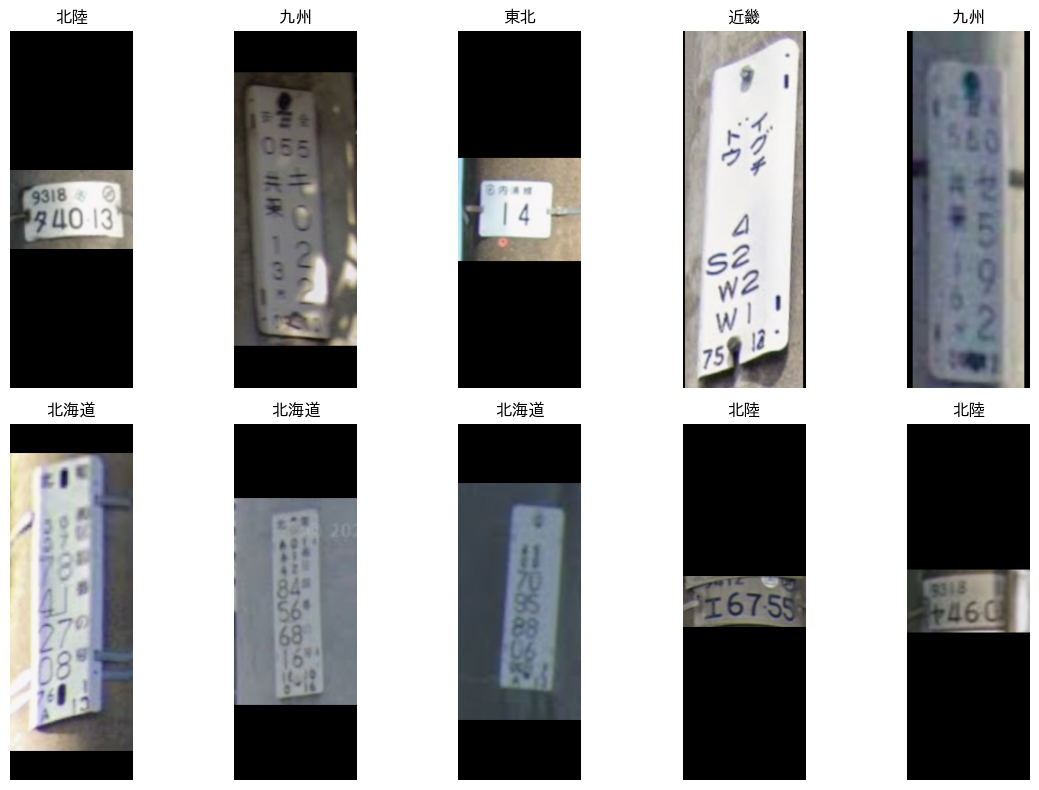

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

# 保存したファイルを読み込む
X_train = np.load("./regions_X_train1.npy")
y_train = np.load("./regions_y_train1.npy")

# クラス名の定義（表示用）
classes = ["北海道", "東北", "関東", "中部", "北陸", "近畿", "中国", "四国", "九州", "沖縄"]

# 画像を表示する設定
plt.figure(figsize=(12, 8))

# 最初の10枚を表示してみる
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])  # 画像を表示
    plt.title(classes[y_train[i]]) # 対応するラベルを表示
    plt.axis('off') # 軸を非表示にする

plt.tight_layout()
plt.show()

1. データをロードしています...
画像サイズ: 380 x 131
2. データセットを作成しています...
128
3. 転移学習モデルを構築しています...


/tmp/ipykernel_4549/266361954.py:46: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


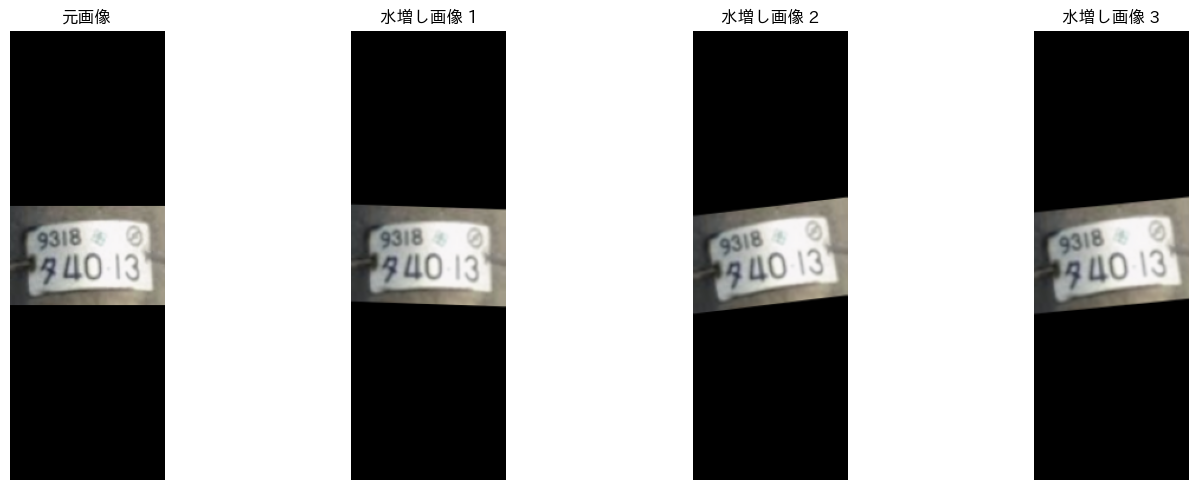

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 380, 131, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 380, 131, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 12, 5, 1280)    │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 380, 131,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 190, 66,   │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 190, 66,   │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 190, 66,   │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 190, 66,   │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 190, 66,   │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 190, 66,   │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 190, 66,   │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 190, 66,   │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 190, 66,   │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 190, 66,   │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 190, 66,   │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 191, 67,   │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 95, 33,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 95, 33,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 95, 33,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 95, 33,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

4. 学習を開始します...
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.1406 - loss: 2.6122 - val_accuracy: 0.3030 - val_loss: 1.9161 - learning_rate: 0.0010
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.2500 - loss: 2.0167 - val_accuracy: 0.3030 - val_loss: 1.5926 - learning_rate: 0.0010
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 786ms/step - accuracy: 0.3750 - loss: 1.7182 - val_accuracy: 0.4545 - val_loss: 1.3749 - learning_rate: 0.0010
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.4375 - loss: 1.4002 - val_accuracy: 0.5455 - val_loss: 1.2255 - learning_rate: 0.0010
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 6s 788ms/step - accuracy: 0.5547 - loss: 1.0855 - val_accuracy: 0.5152 - val_loss: 1.1338 - learning_rate: 0.0010
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.6250 - loss: 0.9535 - val_accuracy: 0.6061 - val_loss: 1.0361 - learning_rate: 0.0010
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 802ms/step - accuracy: 0.6406 - loss: 0.9095 - val_accura

In [8]:
import numpy as np
import tensorflow as tf
import time
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, RandomRotation, RandomZoom, Rescaling
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Flatten
import matplotlib.pyplot as plt

print("1. データをロードしています...")
# 保存した画像データをロード
X_train2 = np.load("./regions_X_train1.npy", allow_pickle=True)
X_test2 = np.load("./regions_X_test1.npy", allow_pickle=True)
y_train2 = np.load("./regions_y_train1.npy", allow_pickle=True)
y_test2 = np.load("./regions_y_test1.npy", allow_pickle=True)

# 画像の高さと幅をデータから自動取得
IMG_HEIGHT = X_train2.shape[1]
IMG_WIDTH = X_train2.shape[2]
print(f"画像サイズ: {IMG_HEIGHT} x {IMG_WIDTH}")

print("2. データセットを作成しています...")
# 各画素値を0-1の範囲で正規化
X_train2 = X_train2.astype(np.float32) / 255.0
X_test2 = X_test2.astype(np.float32) / 255.0
y_train2 = y_train2.astype(np.float32)
y_test2 = y_test2.astype(np.float32)

train_dataset = tf.data.Dataset.from_tensor_slices((X_train2, y_train2))
test_dataset = tf.data.Dataset.from_tensor_slices((X_test2, y_test2))

batch_size = 16
print(len(train_dataset))
shuffle_buffer_size = len(train_dataset)
epochs = 50

# バッチ化とシャッフル
train_dataset2 = train_dataset.shuffle(shuffle_buffer_size).batch(batch_size)
test_dataset2 = test_dataset.batch(batch_size)

print("3. 転移学習モデルを構築しています...")
time1=time.time()
# 【基盤モデル】ImageNetで学習済みの「MobileNetV2」の目を借りる
base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False, # 元の分類層（犬猫判定など）は不要なので捨てる
    weights='imagenet'
)
base_model.trainable = False

data_augmentation = Sequential([
  tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
  RandomRotation(0.03), # 少し回転
  RandomZoom(0.03),     # 少しズーム
])
import matplotlib.pyplot as plt
import tensorflow as tf

# 確認のために元となる画像を1枚選ぶ（ここでは正規化済みのX_train2の最初の画像）
sample_image = X_train2[0]

# グラフのサイズ設定
plt.figure(figsize=(15, 5))

# 1. 左端に元の画像を表示
plt.subplot(1, 4, 1)
plt.imshow(sample_image)
plt.title("元画像")
plt.axis('off')

# モデルに入れるためにバッチ次元を追加（1枚の画像 → 1枚ずつの束にする）
image_batch = tf.expand_dims(sample_image, 0)

# 2. 水増しを3回適用して横に並べて表示
for i in range(3):
    # training=True を指定することで、ランダムな水増し機能を強制的にオンにする
    augmented_image = data_augmentation(image_batch, training=True)

    # バッチ次元を外して元の画像データに戻す
    img_to_show = augmented_image[0]

    plt.subplot(1, 4, i + 2)
    plt.imshow(img_to_show)
    plt.title(f"水増し画像 {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# 新しいモデルの構築
model = Sequential([
    Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # MobileNetV2は「-1〜1」の値を要求するため、現在の「0〜1」から変換
    Rescaling(scale=2.0, offset=-1.0),

    data_augmentation,

    # ここで学習済みの基盤モデルを通す
    base_model,

    # 判定層へ
    GlobalAveragePooling2D(),
    #Flatten(),
    Dropout(0.5),
    Dense(10, activation='softmax') # 10クラス分類
])

# コンパイル
model.compile(
    optimizer=Adam(learning_rate=0.001), # 転移学習の最初は少し早めでOK
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 構造を表示
model.summary()
base_model.summary()

# コールバック設定
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',   # ← val_lossからval_accuracyに変更
        patience=20,
        restore_best_weights=True,
        mode='max'                # ← accuracyは大きいほど良いのでmax
    ),
]


print("4. 学習を開始します...")
history = model.fit(
    train_dataset2,
    epochs=epochs,
    validation_data=test_dataset2,
    callbacks=callbacks
)


5. 学習結果をグラフで表示します...


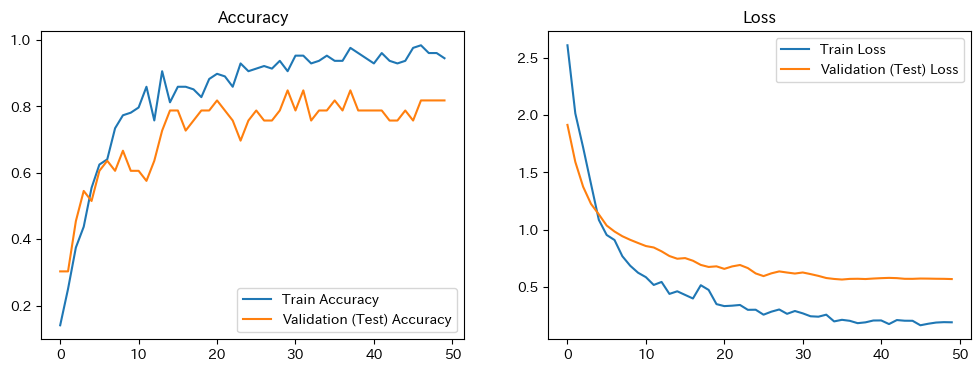

6. テストデータでの最終評価...
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 286ms/step - accuracy: 0.8485 - loss: 0.6163


[0.6162611842155457, 0.8484848737716675]

In [9]:
print("5. 学習結果をグラフで表示します...")
# 学習の推移をグラフ化
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation (Test) Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation (Test) Loss')
plt.legend()
plt.title('Loss')
plt.show()
print("6. テストデータでの最終評価...")
model.evaluate(test_dataset2)